<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Primer%20Corte/02_Generacion_de_variables_aletorias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nicolas Bernal Rubio
## **Simulacion Estadistica**

### *generacion de variables aleatorias*




In [3]:
install.packages("car")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’




## 1.Ejemplo rbeta

* Se busca generar una serie de datos que provienen de una distribucion beta y vamos a compararlos con una distribucion beta teorica para comparar que tanto se aproxima nuestros datos generados a los teoricos luego un box plot para mirar como se comportar en su media y por ultimo un qqPlot (libreria car) lo que genera una banda de confianza del 95% sombreada donde se observa que nuestros datos se mantienen dentro y en el ultimo ejemplo como se dispersan por fuera de la banda de confianza lo que lleva a rechazar la hipotesis de que provienen de una beta (solo ejemplo)

* Luego se puede aplicar prueba de kolmogorov-smitnok(prueba de bandas de ajuste) la cual podemos generar la hipotesis nula y la hipotesis alternativa las cuales podemos analizar y aceptar o rechazar alguna dependieno de una p-value > $\alpha$ = 0.05

[1] 274  30

[1] 274  30


	Asymptotic two-sample Kolmogorov-Smirnov test

data:  X and rbeta(nsim, shape1, shape2)
D = 0.028, p-value = 0.828
alternative hypothesis: two-sided



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  X and rnorm(nsim, mean = 2, sd = 5)
D = 0.603, p-value < 2.2e-16
alternative hypothesis: two-sided



	Asymptotic two-sample Kolmogorov-Smirnov test

data:  X and rbeta(nsim, shape1 = 2, shape2 = 20)
D = 0.651, p-value < 2.2e-16
alternative hypothesis: two-sided


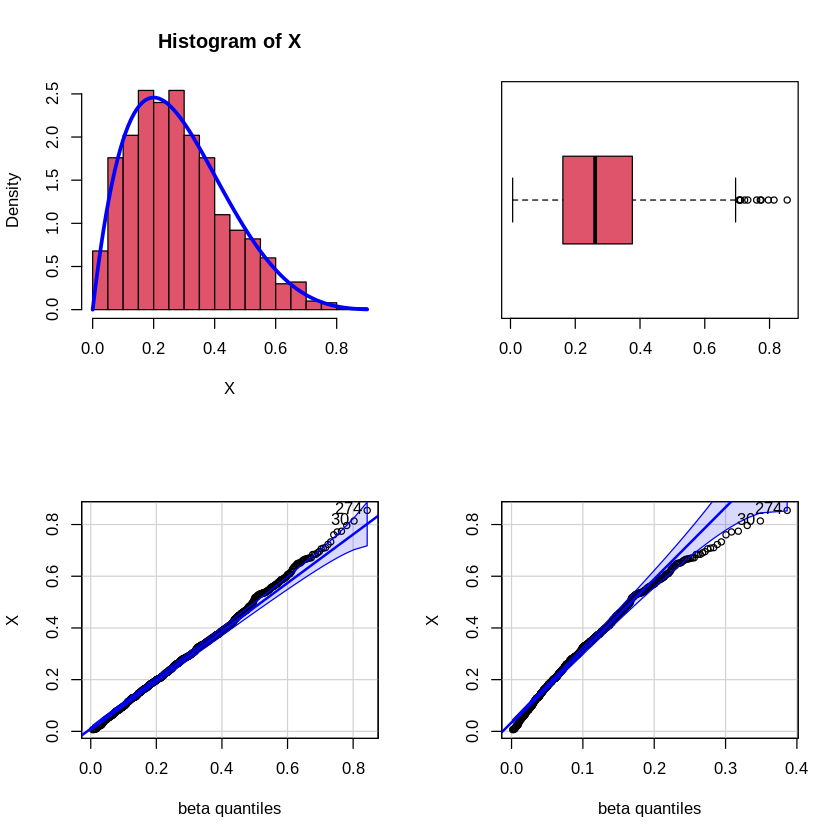

In [15]:
library(car)

nsim = 1000
shape1 = 2
shape2 = 5

X = rbeta(nsim,shape1,shape2)


par(mfrow = c(2,2))
hist(X, freq = FALSE,breaks = "FD",col = 2)
curve(dbeta(x,shape1,shape2),add = TRUE,col = "blue",lwd = 3)
boxplot(X,horizontal = TRUE,col = 2)
qqPlot(X,"beta",shape1 = 2,shape2 = 5,envelope = 0.95)
qqPlot(X,"beta",shape1 = 2,shape2 = 20,envelope = 0.95)

# podemos verificar que efectivamente los datos que estamos generando coinciden con una distribucion beta

# podemos aplicar pruebas como
# prueba de kolmogorov-smitnok(prueba de bandas de ajuste)

# H_0 : que los datos provienen de una dist. beta. (hipotesis nula)

# H_1 : que los datos no provienen de una dist. bet. (hipotesis alternativa)

ks.test(X,rbeta(nsim,shape1,shape2))

ks.test(X,rnorm(nsim,mean=2,sd =5))

ks.test(X,rbeta(nsim,shape1 = 2,shape2 = 20))




## 2.Ejemplo rbinom

* En este ejemplo podemos observar exactamente lo mismo que en el ejercicio anterior solo que ahora no podemos usar las funciones de graficacion hist ni tampoco curve ya que rbinom corresponde a una f.m.p por lo que usamos plot y line

[1] 6

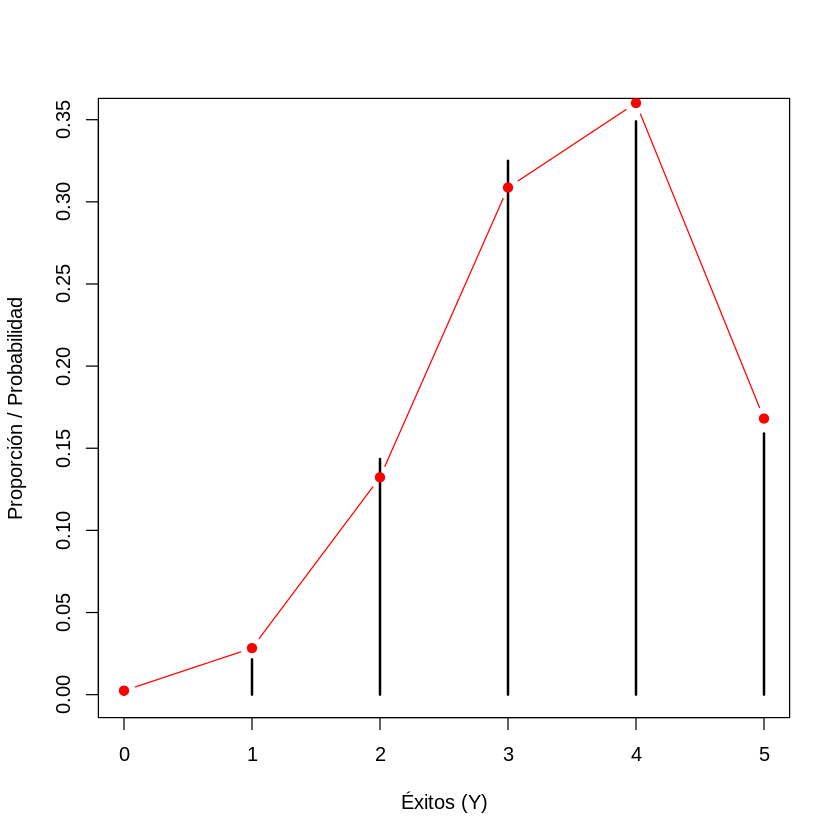

In [14]:

nsim = 2000

Y = rbinom(nsim, size = 5, prob = 0.70)
Z = table(Y) / nsim
dim(Z)

plot(Z, type = "h", lwd = 2, ylab = "Proporción / Probabilidad", xlab = "Éxitos (Y)")

prob_teorica = dbinom(0:5, size = 5, prob = 0.70)

lines(0:5, prob_teorica, col = "red", type = "b", pch = 19)

## Simulacion estadistica
### 4:00 ~ 6:00
### 2/09/2026



## Metodo Inversion

### Definicion

* Se fundamenta en el Teorema de la Transformación Inversa: si $U$ es una variable aleatoria continua con distribución uniforme en el intervalo $(0, 1)$ y $F(x)$ es una función de distribución acumulada (F.D.A.) continua y estrictamente creciente, entonces la variable aleatoria:
$$X = F^{-1}(U)$$

## 1.ejemplo rgamma

* vamos a usar una propiedad muy importante de como podemos tener dos procesos de una distribucion gamma de funcion de densidad y convertirle a una beta y lo probaremos tomando

$$X_1 ∼ rgamma(\alpha,1)$$
$$X_2 ∼ rgamma(\beta,1)$$

$$X = X_1 / (X_1 + X_2) \sim beta(\alpha,\beta)$$

[1] 1791 1040


	Asymptotic two-sample Kolmogorov-Smirnov test

data:  X and rbeta(nsim, alpha, beta)
D = 0.024, p-value = 0.6121
alternative hypothesis: two-sided


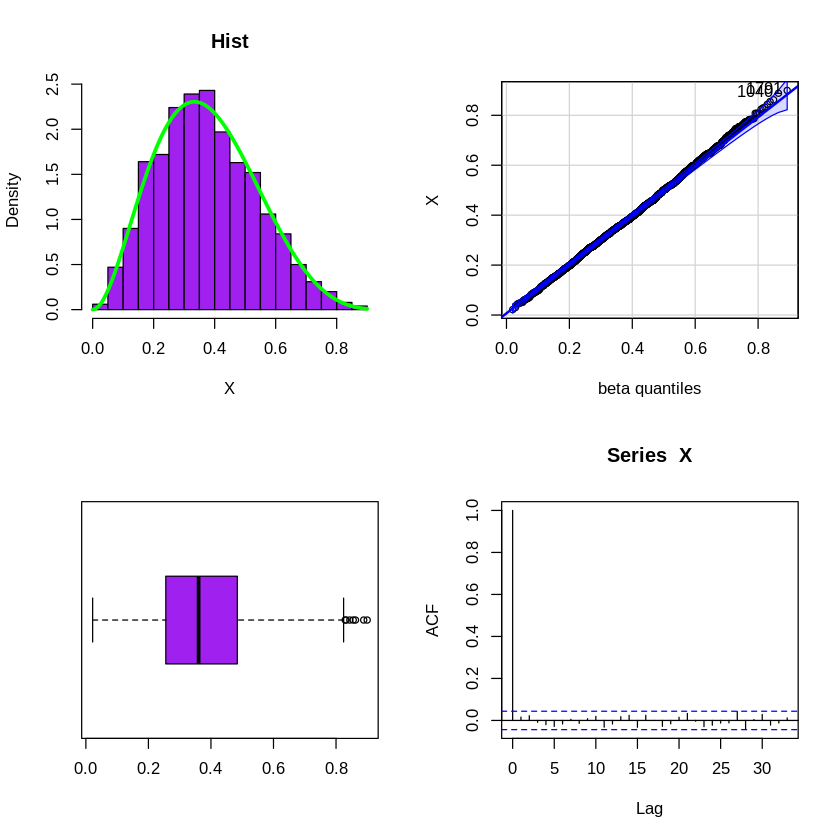

In [16]:


library(car)

nsim = 2000

alpha = 3

beta = 5

x1 = rgamma(nsim,shape = alpha,1)

x2 = rgamma(nsim,shape = beta,1)

X = x1 / (x1 + x2)

par(mfrow = c(2,2))
hist(X,freq = FALSE,breaks = "FD",col = "purple",main = "Hist")
curve(dbeta(x,shape1 = alpha,shape2 = beta),add = TRUE,lwd = 3,col = "green")
qqPlot(X,"beta",shape1 = alpha,shape2 = beta )
boxplot(X,horizontal = TRUE,col = "purple")
acf(X)


ks.test(X,rbeta(nsim,alpha,beta))


## 2.ejemplo

### 1. Función de Densidad de Probabilidad (f.d.p.)
Dado $X \sim \text{Exp}(\lambda)$ con $x > 0$ y $\lambda > 0$:

$$f_X(x) = \lambda e^{-\lambda x}$$

### 2. Función de Distribución Acumulada (F.D.A.)
Para obtener la probabilidad acumulada $F_X(x) = P(X \le x)$, integramos desde el límite inferior $0$ hasta $x$:

$$F_X(x) = \int_{0}^{x} \lambda e^{-\lambda t} \, dt$$

$$F_X(x) = \left[ -e^{-\lambda t} \right]_{0}^{x} = -e^{-\lambda x} - (-e^{0})$$

$$F_X(x) = 1 - e^{-\lambda x}$$

### 3. Inversión (Despejo de $x$)
Igualamos la F.D.A. a una variable aleatoria uniforme $U \sim \text{Unif}(0,1)$:

$$U = 1 - e^{-\lambda x}$$

$$e^{-\lambda x} = 1 - U$$

$$\ln(e^{-\lambda x}) = \ln(1 - U)$$

$$-\lambda x = \ln(1 - U)$$

$$x = -\frac{\ln(1 - U)}{\lambda}$$


	Asymptotic two-sample Kolmogorov-Smirnov test

data:  X and rexp(3000, 5)
D = 0.015333, p-value = 0.8723
alternative hypothesis: two-sided


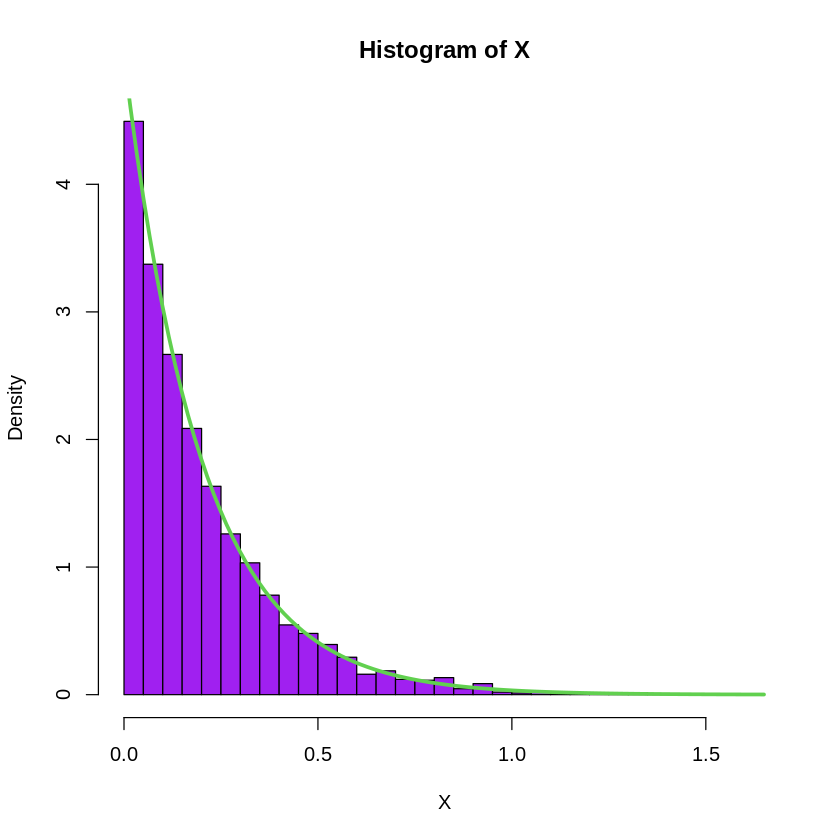

In [18]:
genereexp = function(nsim,lambda){
  U = runif(nsim)
  X = log(U)/-lambda
  return(X)
}

X = genereexp(nsim = 3000,lambda = 5)

hist(X,freq = FALSE,breaks = "FD",col = "purple")
curve(dexp(x,5),add = TRUE,col = 3, lwd = 3)
ks.test(X,rexp(3000,5))

## Conclusion
* podemos observar que efectivamente los datos que hemos pedido provienen de una exp lo cual hemos generado datos aleatorios provenientes de una distribucion uniforme

## realizar las siguentes verificaciones por el metodo de inversion

* 4) werbull(alpha,1)

* 5) gumbel(0,1)

* 6) pareto(alpha)